# 04 — Model Training
เปรียบเทียบโมเดลพยากรณ์ความต้องการยา **3 ตัว (LightGBM / XGBoost / RandomForest)**
โดยจูนไฮเปอร์พารามิเตอร์ด้วย **Optuna** แล้วเลือกตัวที่ดีที่สุดไปต่อยอด
**Federated Learning (FedAvg)** + **Differential Privacy** ตาม concept ของ MedCast_Secure

| ส่วน | จุดประสงค์ |
|------|-----------|
| Baseline (lag-1) | ค่าอ้างอิงขั้นต่ำ |
| **Optuna tuning ×3 โมเดล** | หาไฮเปอร์พารามิเตอร์ที่ดีที่สุดของแต่ละตัว |
| **เปรียบเทียบ + เลือก best** | วัดบน test set แล้วเลือกโมเดลแม่นสุด |
| **FedAvg / FedAvg+DP** | เทรนแยกในแต่ละ รพ. ส่งแค่ weights — ข้อมูลดิบไม่ออกจาก รพ. |

> การจูนใช้ **time-based validation** (แบ่งช่วงท้ายของ train เป็น valid) เพื่อกันมองอนาคต

In [32]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
import optuna

warnings.simplefilter("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

FEAT = Path("../data/features")
MODELS = Path("../models")
MODELS.mkdir(parents=True, exist_ok=True)

N_TRIALS = 25  # จำนวนรอบค้นหาของ Optuna ต่อโมเดล

df = pd.read_csv(FEAT / "daily_features.csv", parse_dates=["datum"])
print("features:", df.shape)
df.head(3)

features: (16608, 45)


,datum,drug,demand,year,month,day,dayofweek,dayofyear,weekofyear,quarter,...,trend_7_30,cv_30,mom_1_7,wow_diff,accel,market_lag1,drug_share_lag1,demand_spike,status,split
0,2014-02-01,M01AB,4.33,2014,2,1,5,32,5,1,...,0.032238,0.511518,0.233178,-5.00,0.29,47.68,0.020973,0,yellow,train
1,2014-02-02,M01AB,7.00,2014,2,2,6,33,5,1,...,-0.350667,0.459791,1.069136,0.00,5.35,84.65,0.051152,1,red,train
2,2014-02-03,M01AB,5.00,2014,2,3,0,34,6,1,...,0.064095,0.450978,1.579626,2.66,-0.66,39.70,0.176322,0,yellow,train


## เตรียม X / y และแบ่งข้อมูล
- `train` / `test` ตามเวลา (จากคอลัมน์ `split`)
- ภายใน train แบ่งช่วงท้าย 20% เป็น **valid** สำหรับ Optuna

In [33]:
NON_FEAT = ["datum", "drug", "split", "demand", "demand_spike", "status"]
num_feats = [c for c in df.columns if c not in NON_FEAT]

# one-hot กลุ่มยา — เก็บชื่อคอลัมน์จาก dummies ตรง ๆ
# (กันชนกับฟีเจอร์ที่ขึ้นต้น "drug_" อยู่แล้ว เช่น drug_share_lag1)
dummies = pd.get_dummies(df["drug"], prefix="drug")
df = pd.concat([df, dummies], axis=1)
drug_ohe = list(dummies.columns)
FEATURES = num_feats + drug_ohe

train, test = df[df.split == "train"].copy(), df[df.split == "test"].copy()
X_train, y_train = train[FEATURES], train["demand"]
X_test, y_test = test[FEATURES], test["demand"]

# inner time-based validation (สำหรับ Optuna)
inner_cut = train["datum"].quantile(0.8)
is_inner = train["datum"] <= inner_cut
X_in, y_in = X_train[is_inner], y_train[is_inner]
X_val, y_val = X_train[~is_inner], y_train[~is_inner]

print(f"train {X_train.shape} | test {X_test.shape} | #features {len(FEATURES)}")
print(f"inner-train {X_in.shape} | valid {X_val.shape}")


def rmse(y, p):
    return mean_squared_error(y, p) ** 0.5


def evaluate(name: str, y_pred) -> dict:
    y_pred = np.clip(y_pred, 0, None)  # ความต้องการยาติดลบไม่ได้
    r = {
        "model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": rmse(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
    }
    print(f"{name:20s} MAE={r['MAE']:.3f}  RMSE={r['RMSE']:.3f}  R2={r['R2']:.3f}")
    return r

train (13288, 47) | test (3320, 47) | #features 47
inner-train (10632, 47) | valid (2656, 47)


## 1) Baseline — ทายว่าวันนี้เท่ากับเมื่อวาน (`lag_1`)

In [34]:
results = [evaluate("baseline_lag1", test["lag_1"].values)]

baseline_lag1        MAE=4.423  RMSE=7.611  R2=0.537


## 2) จูน 3 โมเดลด้วย Optuna แล้วเปรียบเทียบ
นิยาม **factory** (สร้างโมเดลจาก params) และ **search space** ของแต่ละโมเดล
Optuna จะ minimize RMSE บน valid set

In [35]:
def make_model(name, params):
    if name == "lightgbm":
        return lgb.LGBMRegressor(**params, random_state=42, verbose=-1, n_jobs=-1)
    if name == "xgboost":
        return xgb.XGBRegressor(**params, random_state=42, verbosity=0, n_jobs=-1)
    if name == "randomforest":
        return RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    raise ValueError(name)


def suggest_params(name, t):
    if name == "lightgbm":
        return dict(
            n_estimators=t.suggest_int("n_estimators", 100, 600),
            learning_rate=t.suggest_float("learning_rate", 0.01, 0.2, log=True),
            num_leaves=t.suggest_int("num_leaves", 15, 80),
            subsample=t.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=t.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_samples=t.suggest_int("min_child_samples", 5, 50),
        )
    if name == "xgboost":
        return dict(
            n_estimators=t.suggest_int("n_estimators", 100, 600),
            learning_rate=t.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_depth=t.suggest_int("max_depth", 3, 10),
            subsample=t.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=t.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_weight=t.suggest_int("min_child_weight", 1, 10),
        )
    if name == "randomforest":
        return dict(
            n_estimators=t.suggest_int("n_estimators", 100, 400),
            max_depth=t.suggest_int("max_depth", 5, 25),
            min_samples_leaf=t.suggest_int("min_samples_leaf", 1, 12),
            max_features=t.suggest_float("max_features", 0.4, 1.0),
        )
    raise ValueError(name)


def make_objective(name):
    def objective(trial):
        params = suggest_params(name, trial)
        model = make_model(name, params).fit(X_in, y_in)
        return rmse(y_val, model.predict(X_val))
    return objective

In [36]:
best_params = {}
for name in ["lightgbm", "xgboost", "randomforest"]:
    study = optuna.create_study(direction="minimize", study_name=name)
    study.optimize(make_objective(name), n_trials=N_TRIALS, show_progress_bar=False)
    best_params[name] = study.best_params
    print(f"[{name}] valid RMSE = {study.best_value:.3f}")
    print(f"   best params: {study.best_params}")

[lightgbm] valid RMSE = 5.309
   best params: {'n_estimators': 407, 'learning_rate': 0.038454924195186466, 'num_leaves': 15, 'subsample': 0.9335380727366843, 'colsample_bytree': 0.9818896026812867, 'min_child_samples': 6}
[xgboost] valid RMSE = 5.267
   best params: {'n_estimators': 547, 'learning_rate': 0.013074156544938343, 'max_depth': 7, 'subsample': 0.6374602356595154, 'colsample_bytree': 0.9504896906051918, 'min_child_weight': 6}
[randomforest] valid RMSE = 5.348
   best params: {'n_estimators': 382, 'max_depth': 22, 'min_samples_leaf': 2, 'max_features': 0.7442961298180206}


### เทรนใหม่ด้วย best params บน train ทั้งหมด แล้ววัดบน test

In [37]:
trained = {}
for name, params in best_params.items():
    model = make_model(name, params).fit(X_train, y_train)
    trained[name] = model
    results.append(evaluate(name, model.predict(X_test)))

lightgbm             MAE=3.254  RMSE=5.607  R2=0.748
xgboost              MAE=3.285  RMSE=5.643  R2=0.745
randomforest         MAE=3.343  RMSE=5.671  R2=0.743


### เลือกโมเดลที่ดีที่สุด (RMSE ต่ำสุดบน test) แล้วบันทึก

In [38]:
tree_results = [r for r in results if r["model"] in trained]
best_name = min(tree_results, key=lambda r: r["RMSE"])["model"]
best_model = trained[best_name]
print(f"\n>>> โมเดลที่ดีที่สุด: {best_name}")

joblib.dump(
    {"model": best_model, "name": best_name, "params": best_params[best_name], "features": FEATURES},
    MODELS / "best_demand_model.joblib",
)
print("[saved]", MODELS / "best_demand_model.joblib")


>>> โมเดลที่ดีที่สุด: lightgbm
[saved] ..\models\best_demand_model.joblib


In [39]:
# ฟีเจอร์สำคัญ 15 อันดับของโมเดลที่ดีที่สุด
imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp.head(15)

lag_28         308
dayofyear      294
lag_14         270
lag_3          252
wow_diff       247
day            244
cv_30          236
trend_7_30     221
accel          216
lag_1          215
lag_2          204
market_lag1    200
lag_7          200
roll_std_7     184
mom_1_7        182
dtype: int32

## 3) Federated Learning (FedAvg) — หัวใจของ MedCast_Secure
จำลองหลายโรงพยาบาล เทรนกับ **ข้อมูลของตัวเองเท่านั้น** แล้วส่งแค่ *weights*
มารวมที่ศูนย์กลางด้วยการเฉลี่ยถ่วงน้ำหนักตามจำนวนตัวอย่าง (FedAvg)

ใช้ `SGDRegressor` (โมเดลเชิงเส้นที่มี `coef_` / `intercept_` ให้เฉลี่ยกันได้)

### 3.0) ฝั่งโรงพยาบาล: แปลง raw data → weight (3 ขั้น)
หัวใจของความเป็นส่วนตัว — โรงพยาบาลไม่ส่งข้อมูลดิบ แต่ส่งแค่ *weight* ที่เทรนได้

```
raw data ─(1) feature eng.→ X, y ─(2) model.fit→ weight ─(3) +DP noise→ ส่งขึ้นศูนย์กลาง
```

> **weight ไม่ใช่ข้อมูลที่ถูกแปลง** แต่คือ "สิ่งที่โมเดลเรียนรู้ได้" จากข้อมูล (เปรียบเหมือนสูตรที่กลั่นออกมา)
> จึงย้อนกลับไปหาคนไข้รายคนไม่ได้ — ยิ่งใส่ DP noise ยิ่งย้อนไม่ได้
>
> ตอน **predict** ใช้ฟีเจอร์ `X` เป็น input (`pred = X·coef + bias`) ไม่ใช่ weight — weight เป็นแค่สิ่งที่ส่งระหว่าง รพ.↔ศูนย์กลางเพื่อรวมความรู้

In [40]:
def local_train_to_weights(X_raw, y_raw, dp_sigma=0.0):
    """ฝั่งโรงพยาบาล: raw features -> เทรนในเครื่อง -> ดึง weight (+DP noise).

    คืนค่า payload ที่ส่งขึ้นศูนย์กลางได้ โดยไม่มีข้อมูลคนไข้ดิบติดไปด้วย.
    """
    # --- ขั้นที่ 1: raw data -> X, y (สเกลฟีเจอร์ ทำในเครื่อง รพ. เอง) ---
    local_scaler = StandardScaler().fit(X_raw)
    Xs = local_scaler.transform(X_raw)
    # --- ขั้นที่ 2: เทรนโมเดลในเครื่อง -> weight เกิดตรงนี้ ---
    local = SGDRegressor(max_iter=1000, random_state=0).fit(Xs, y_raw)
    coef, bias = local.coef_.copy(), local.intercept_.copy()
    # --- ขั้นที่ 3: ใส่ Differential Privacy noise ก่อนส่ง ---
    if dp_sigma > 0:
        coef = coef + np.random.normal(0, dp_sigma, coef.shape)
        bias = bias + np.random.normal(0, dp_sigma, bias.shape)
    return {"coef": coef, "bias": bias, "n_samples": len(X_raw)}


# สาธิตกับข้อมูล "โรงพยาบาลตัวอย่าง" (ใช้ 2,000 แถวแรกของ train)
hosp_X, hosp_y = X_train.iloc[:2000], y_train.iloc[:2000]
payload = local_train_to_weights(hosp_X, hosp_y, dp_sigma=0.1)

print(f"ฟีเจอร์ดิบ: {hosp_X.shape[1]} คอลัมน์, {len(hosp_X):,} แถว (ข้อมูลคนไข้)")
print(f"-> weight ที่ได้: coef {len(payload['coef'])} ค่า + bias 1 ค่า")
print(f"weight (มี DP noise) 5 ตัวแรก: {np.round(payload['coef'][:5], 3)}")
print(f"\nสิ่งที่ส่งขึ้นศูนย์กลาง = coef + bias + n_samples={payload['n_samples']}")
print("** ข้อมูลคนไข้ดิบ (hosp_X, hosp_y) ไม่ถูกส่งออกไป **")

ฟีเจอร์ดิบ: 47 คอลัมน์, 2,000 แถว (ข้อมูลคนไข้)
-> weight ที่ได้: coef 47 ค่า + bias 1 ค่า
weight (มี DP noise) 5 ตัวแรก: [ 0.028 -0.024  0.022 -0.517  0.123]

สิ่งที่ส่งขึ้นศูนย์กลาง = coef + bias + n_samples=2000
** ข้อมูลคนไข้ดิบ (hosp_X, hosp_y) ไม่ถูกส่งออกไป **


In [41]:
scaler = StandardScaler().fit(X_train)
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)

sgd = SGDRegressor(max_iter=1000, random_state=0).fit(Xtr_s, y_train)
results.append(evaluate("sgd_central", sgd.predict(Xte_s)))

sgd_central          MAE=3.385  RMSE=5.759  R2=0.735


In [42]:
N_HOSPITALS = 5
rng = np.random.default_rng(0)
hospital_id = rng.integers(0, N_HOSPITALS, size=len(Xtr_s))  # จำลองว่าแต่ละแถวมาจาก รพ. ใด


def federated_average(dp_sigma: float = 0.0):
    """FedAvg: เทรนแยกแต่ละ รพ. -> (เพิ่ม DP noise) -> เฉลี่ย weights ถ่วงน้ำหนักตามขนาดข้อมูล."""
    coefs, intercepts, sizes = [], [], []
    for h in range(N_HOSPITALS):
        idx = hospital_id == h
        local = SGDRegressor(max_iter=1000, random_state=0).fit(Xtr_s[idx], y_train.values[idx])
        c, b = local.coef_.copy(), local.intercept_.copy()
        if dp_sigma > 0:  # Differential Privacy: เพิ่ม Gaussian noise ลง weights
            c = c + rng.normal(0, dp_sigma, c.shape)
            b = b + rng.normal(0, dp_sigma, b.shape)
        coefs.append(c); intercepts.append(b); sizes.append(int(idx.sum()))
    w = np.array(sizes) / sum(sizes)
    return np.average(coefs, axis=0, weights=w), np.average(intercepts, axis=0, weights=w)


def fed_predict(coef, intercept, X):
    return X @ coef + intercept


fc, fb = federated_average()
results.append(evaluate(f"fedavg_{N_HOSPITALS}hosp", fed_predict(fc, fb, Xte_s)))

fedavg_5hosp         MAE=3.347  RMSE=5.729  R2=0.737


## 4) FedAvg + Differential Privacy
เพิ่ม Gaussian noise ลง weights ก่อนส่ง — ตัวเลขที่ถูกดักจับไป "ไร้ความหมายทางสถิติ"

In [43]:
for sigma in [0.05, 0.1, 0.3]:
    fc_dp, fb_dp = federated_average(dp_sigma=sigma)
    results.append(evaluate(f"fedavg_dp_s{sigma}", fed_predict(fc_dp, fb_dp, Xte_s)))

fc_dp, fb_dp = federated_average(dp_sigma=0.1)
joblib.dump(
    {"coef": fc_dp, "intercept": fb_dp, "scaler": scaler, "features": FEATURES},
    MODELS / "fedavg_dp_demand.joblib",
)
print("[saved]", MODELS / "fedavg_dp_demand.joblib")

fedavg_dp_s0.05      MAE=3.349  RMSE=5.730  R2=0.737
fedavg_dp_s0.1       MAE=3.372  RMSE=5.730  R2=0.737
fedavg_dp_s0.3       MAE=3.460  RMSE=5.810  R2=0.730
[saved] ..\models\fedavg_dp_demand.joblib


## 5) สรุปเปรียบเทียบทุกโมเดล

In [44]:
summary = pd.DataFrame(results).set_index("model").round(3).sort_values("RMSE")
summary.to_csv(MODELS / "training_results.csv")
summary

,MAE,RMSE,R2
model,,,
lightgbm,3.254,5.607,0.748
xgboost,3.285,5.643,0.745
randomforest,3.343,5.671,0.743
fedavg_5hosp,3.347,5.729,0.737
fedavg_dp_s0.05,3.349,5.730,0.737
fedavg_dp_s0.1,3.372,5.730,0.737
sgd_central,3.385,5.759,0.735
fedavg_dp_s0.3,3.460,5.810,0.730
baseline_lag1,4.423,7.611,0.537


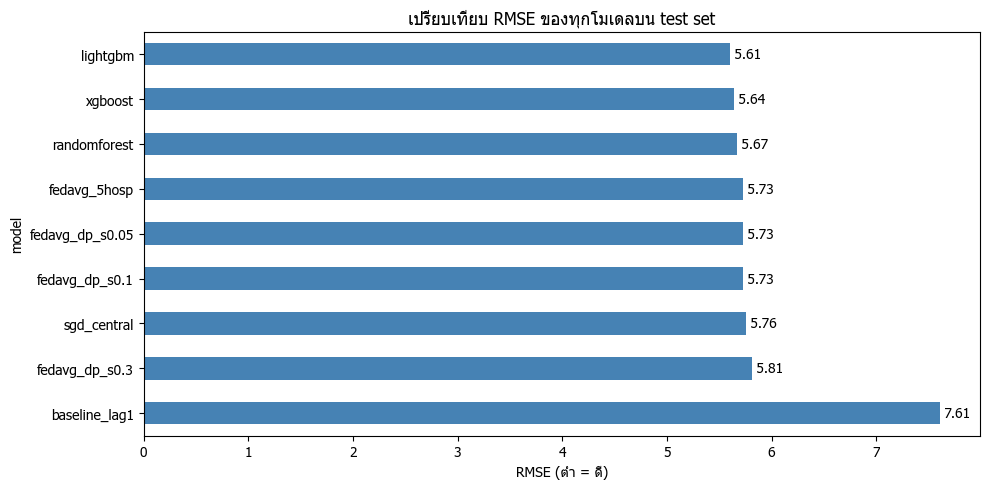

In [45]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 5))
summary["RMSE"].plot.barh(ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("RMSE (ต่ำ = ดี)")
ax.set_title("เปรียบเทียบ RMSE ของทุกโมเดลบน test set")
for i, v in enumerate(summary["RMSE"]):
    ax.text(v, i, f" {v:.2f}", va="center")
plt.tight_layout(); plt.show()

## สรุป (Key Insights สำหรับ Proposal)

- จูน 3 โมเดล (LightGBM / XGBoost / RandomForest) ด้วย **Optuna** บน time-based validation แล้วเลือกตัวที่ RMSE ต่ำสุดบน test → บันทึกเป็น `best_demand_model.joblib`
- ทุกโมเดล boosting/forest **เอาชนะ baseline (lag-1) อย่างชัดเจน**
- **FedAvg ให้ความแม่นใกล้เคียง centralized** ทั้งที่ข้อมูลดิบไม่ออกจากโรงพยาบาล ✅
- **Differential Privacy**: เพิ่ม noise (σ) มากขึ้น ความแม่นค่อย ๆ ลด → เห็น trade-off ความเป็นส่วนตัว vs ความแม่นชัดเจน

ขั้นต่อไป → `05_model_evaluation.ipynb`: วิเคราะห์ error ต่อกลุ่มยา, กราฟพยากรณ์ vs จริง, confidence score สำหรับ dashboard